In [0]:

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ordinal_classification").getOrCreate()

spark = SparkSession.builder.appName("Mobile Price Analysis").getOrCreate()
df = spark.read.csv('dbfs:/FileStore/tables/train.csv', header=True, inferSchema=True)

# Number of rows and columns
num_rows = df.count()
num_cols = len(df.columns)
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")

Number of Rows: 2000
Number of Columns: 21


In [0]:
#Percent of missing values by columns

from pyspark.sql.functions import col, count, when

missing_percentage = df.select([(count(when(col(c).isNull(), c))/num_rows).alias(c) for c in df.columns])
missing_percentage.show()


+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+---+----+----+---------+-------+------------+----+-----------+
|battery_power|blue|clock_speed|dual_sim| fc|four_g|int_memory|m_dep|mobile_wt|n_cores| pc|px_height|px_width|ram|sc_h|sc_w|talk_time|three_g|touch_screen|wifi|price_range|
+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+---+----+----+---------+-------+------------+----+-----------+
|          0.0| 0.0|        0.0|     0.0|0.0|   0.0|       0.0|  0.0|      0.0|    0.0|0.0|      0.0|     0.0|0.0| 0.0| 0.0|      0.0|    0.0|         0.0| 0.0|        0.0|
+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+---+----+----+---------+-------+------------+----+-----------+



In [0]:
#To see the features 
df.printSchema()
df.show()
df.describe().show()



root
 |-- battery_power: integer (nullable = true)
 |-- blue: integer (nullable = true)
 |-- clock_speed: double (nullable = true)
 |-- dual_sim: integer (nullable = true)
 |-- fc: integer (nullable = true)
 |-- four_g: integer (nullable = true)
 |-- int_memory: integer (nullable = true)
 |-- m_dep: double (nullable = true)
 |-- mobile_wt: integer (nullable = true)
 |-- n_cores: integer (nullable = true)
 |-- pc: integer (nullable = true)
 |-- px_height: integer (nullable = true)
 |-- px_width: integer (nullable = true)
 |-- ram: integer (nullable = true)
 |-- sc_h: integer (nullable = true)
 |-- sc_w: integer (nullable = true)
 |-- talk_time: integer (nullable = true)
 |-- three_g: integer (nullable = true)
 |-- touch_screen: integer (nullable = true)
 |-- wifi: integer (nullable = true)
 |-- price_range: integer (nullable = true)

+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+----+----+----+---------+-------+------------

In [0]:
#Changing feautres to Binary
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def int_to_binary(n):
    return bin(n)[2:]  # [2:] to remove the '0b' prefix

binary_udf = udf(int_to_binary, StringType())

In [0]:
columns_to_convert = ["blue", "dual_sim", "fc", "four_g", "three_g", "touch_screen", "wifi"]  # Replace with your column names

df_with_binary = df
for col_name in columns_to_convert:
    df_with_binary = df_with_binary.withColumn(f"{col_name}_binary", binary_udf(df[col_name]))
df_with_binary.show()


+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+----+----+----+---------+-------+------------+----+-----------+-----------+---------------+---------+-------------+--------------+-------------------+-----------+
|battery_power|blue|clock_speed|dual_sim| fc|four_g|int_memory|m_dep|mobile_wt|n_cores| pc|px_height|px_width| ram|sc_h|sc_w|talk_time|three_g|touch_screen|wifi|price_range|blue_binary|dual_sim_binary|fc_binary|four_g_binary|three_g_binary|touch_screen_binary|wifi_binary|
+-------------+----+-----------+--------+---+------+----------+-----+---------+-------+---+---------+--------+----+----+----+---------+-------+------------+----+-----------+-----------+---------------+---------+-------------+--------------+-------------------+-----------+
|          842|   0|        2.2|       0|  1|     0|         7|  0.6|      188|      2|  2|       20|     756|2549|   9|   7|       19|      0|           0|   1|          1|        

In [0]:
#Means, medians, modes using Pandas tables 
import pandas as pd

# Assuming you've already converted the Spark DataFrame to pandas
pandas_df = df.toPandas()

# Compute Means, Medians, and Modes
means = pandas_df.mean()
medians = pandas_df.median()
modes = pandas_df.mode().iloc[0]  # .mode() returns a DataFrame, so we take the first row

# Combine the Results into a Single pandas DataFrame
summary_df = pd.DataFrame({
    'Means': means,
    'Medians': medians,
    'Modes': modes
})

# Display the results
print(summary_df)


                    Means  Medians   Modes
battery_power  1238.51850   1226.0   618.0
blue              0.49500      0.0     0.0
clock_speed       1.52225      1.5     0.5
dual_sim          0.50950      1.0     1.0
fc                4.30950      3.0     0.0
four_g            0.52150      1.0     1.0
int_memory       32.04650     32.0    27.0
m_dep             0.50175      0.5     0.1
mobile_wt       140.24900    141.0   182.0
n_cores           4.52050      4.0     4.0
pc                9.91650     10.0    10.0
px_height       645.10800    564.0   347.0
px_width       1251.51550   1247.0   874.0
ram            2124.21300   2146.5  1229.0
sc_h             12.30650     12.0    17.0
sc_w              5.76700      5.0     1.0
talk_time        11.01100     11.0     7.0
three_g           0.76150      1.0     1.0
touch_screen      0.50300      1.0     1.0
wifi              0.50700      1.0     1.0
price_range       1.50000      1.5     0.0


In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Class Count with PySpark") \
    .getOrCreate()

class_counts = df.groupBy("price_range").count().orderBy("count", ascending=False)
class_counts.show()


+-----------+-----+
|price_range|count|
+-----------+-----+
|          1|  500|
|          3|  500|
|          2|  500|
|          0|  500|
+-----------+-----+



In [0]:
#the contribution of the categorical variables 

from pyspark.sql import functions as F

selected_features = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]

# Compute the sum for each feature, divide by 500, and then multiply by 100
sums = df.groupBy("price_range").agg(
    *[(F.sum(feature) / 500 * 100).alias(f"{feature}_percentage") for feature in selected_features]
)

# Sort the results by price_range
sorted_sums = sums.orderBy("price_range")

sorted_sums.show()


+-----------+------------------+-------------------+------------------+------------------+-----------------------+------------------+
|price_range|   blue_percentage|dual_sim_percentage| four_g_percentage|three_g_percentage|touch_screen_percentage|   wifi_percentage|
+-----------+------------------+-------------------+------------------+------------------+-----------------------+------------------+
|          0|              48.6|               50.0|51.800000000000004|              74.6|     52.400000000000006|              49.6|
|          1|              49.0|               51.0|52.400000000000006|              75.6|                   52.2|              50.4|
|          2|              48.6|               49.8|              49.4|              77.4|                   47.0|              50.4|
|          3|51.800000000000004|               53.0| 55.00000000000001|              77.0|                   49.6|52.400000000000006|
+-----------+------------------+-------------------+----------

In [0]:
#to find the average of some features 

#Import Necessary Functions:
from pyspark.sql import functions as F

#Specify Your Features:
selected_features = ["battery_power", "clock_speed", "fc", "int_memory", "m_dep", "mobile_wt", "n_cores", "pc", "px_width", "px_height", "ram", "sc_h", "sc_w", "talk_time"]  # Replace these with your actual feature names

#Compute Averages Grouped by Class
averages_by_class_df = df.groupBy("price_range").agg(*[F.avg(feature).alias(f"{feature}_avg") for feature in selected_features])
# Sort the results by price_range
sorted_averages_by_class_df = averages_by_class_df.orderBy("price_range")
sorted_averages_by_class_df.show()



+-----------+-----------------+------------------+------+--------------+-------------------+-------------+-----------+------+------------+-------------+--------+--------+--------+-------------+
|price_range|battery_power_avg|   clock_speed_avg|fc_avg|int_memory_avg|          m_dep_avg|mobile_wt_avg|n_cores_avg|pc_avg|px_width_avg|px_height_avg| ram_avg|sc_h_avg|sc_w_avg|talk_time_avg|
+-----------+-----------------+------------------+------+--------------+-------------------+-------------+-----------+------+------------+-------------+--------+--------+--------+-------------+
|          0|         1116.902|1.5501999999999998| 4.084|        31.174|0.49019999999999986|      140.552|        4.6| 9.574|     1150.27|      536.408| 785.314|  12.324|   5.682|       10.612|
|          1|         1228.868|1.4886000000000008|  4.34|        32.116|  0.523999999999999|       140.51|      4.298| 9.924|    1251.908|      666.892| 1679.49|  12.212|   5.544|       11.362|
|          2|          1228.32

In [0]:
#Finiding the Sd for each price_range
from pyspark.sql import functions as F
import pandas as pd

# Assuming df is your DataFrame
features = [col for col in df.columns if col != 'price_range']

# Compute standard deviation for each feature
stats_df = df.groupBy("price_range").agg(
    *[F.stddev(feature).alias(f"{feature}_stddev") for feature in features]
)

# Sort by price_range
sorted_stats = stats_df.orderBy("price_range")

# Convert the PySpark DataFrame to a Pandas DataFrame
sorted_stats_pd = sorted_stats.toPandas()

# Transpose the Pandas DataFrame for horizontal display
transposed_stats = sorted_stats_pd.transpose()

# Display the transposed Pandas DataFrame
print(transposed_stats)


                               0           1           2           3
price_range             0.000000    1.000000    2.000000    3.000000
battery_power_stddev  410.801305  438.614528  452.863065  414.992261
blue_stddev             0.500305    0.500401    0.500305    0.500176
clock_speed_stddev      0.848941    0.814479    0.804404    0.796450
dual_sim_stddev         0.500501    0.500401    0.500497    0.499599
fc_stddev               4.183772    4.499432    4.347390    4.332399
four_g_stddev           0.500176    0.499924    0.500465    0.497992
int_memory_stddev      18.101023   18.000739   18.441958   17.930377
m_dep_stddev            0.288184    0.286895    0.286215    0.291901
mobile_wt_stddev       36.378319   35.678956   34.320326   34.911994
n_cores_stddev          2.268544    2.311684    2.262546    2.297074
pc_stddev               6.095805    6.124806    5.952861    6.085521
px_height_stddev      372.824164  441.351209  445.789232  483.720179
px_width_stddev       413.001780  

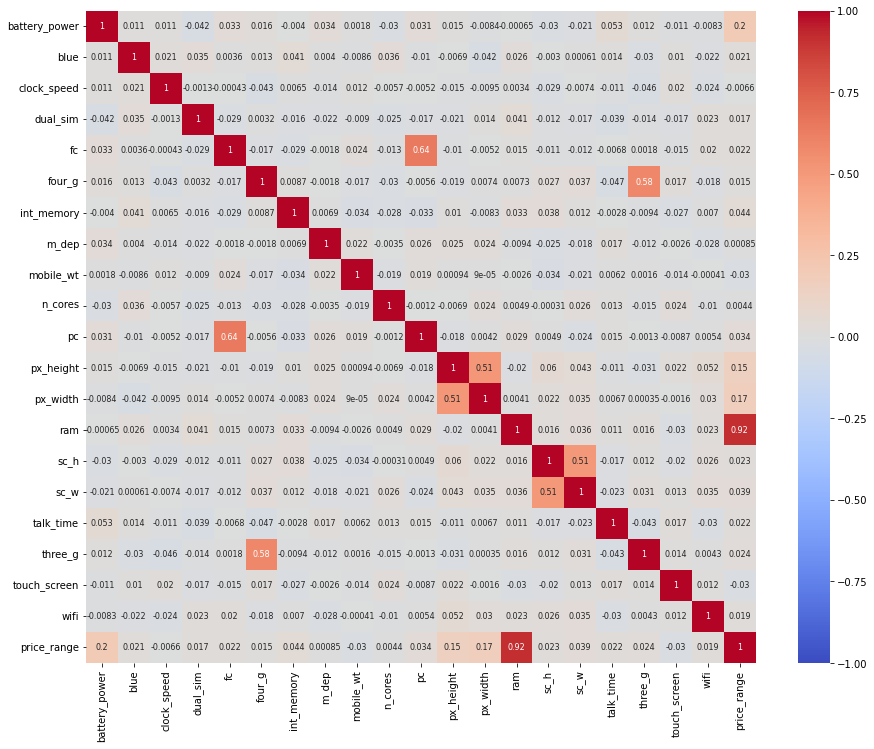

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a dataframe named 'pandas_df'
correlation_matrix = pandas_df.corr()

# Now, you can visualize the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 8})
plt.show()



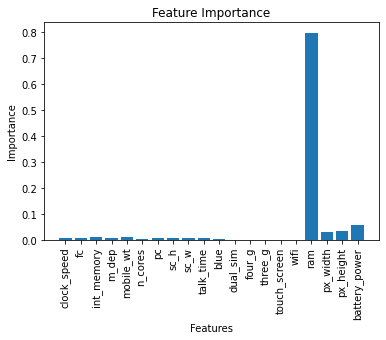

In [0]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Initialize Spark Session
spark = SparkSession.builder \
    .appName("Feature Importance") \
    .getOrCreate()

# 2. Load Data (Assuming you have a CSV file named 'data.csv')
# Note: Make sure to replace 'data.csv' with the path to your file


# 3. Feature Assembling
feature_columns = ['clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 
                   'sc_h', 'sc_w', 'talk_time', 'blue', 'dual_sim', 'four_g', 'three_g', 
                   'touch_screen', 'wifi', 'ram', 'px_width', 'px_height', 'battery_power']
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
assembled_df = assembler.transform(df)

# 4. Train Random Forest Model
# Assuming you're doing classification; if it's regression, you need to replace this
# with RandomForestRegressor and import it accordingly.
rf = RandomForestClassifier(featuresCol="features", labelCol="price_range")
model = rf.fit(assembled_df)

# 5. Extract Feature Importance
feature_importance = model.featureImportances.toArray()  # Convert SparseVector to array

# 6. Visualize Importance
plt.bar(feature_columns, feature_importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=90)  # Rotate x-labels for better readability
plt.show()


In [0]:
# Compute Variance for each column
variance = pandas_df.var()

# Convert the variance Series to a DataFrame for display
variance_df = variance.reset_index()
variance_df.columns = ['Feature', 'Variance']

# Display the DataFrame
variance_df


,Feature,Variance
0,battery_power,1.930884e+05
1,blue,2.501001e-01
2,clock_speed,6.658629e-01
3,dual_sim,2.500348e-01
4,fc,1.884813e+01
5,four_g,2.496626e-01
6,int_memory,3.292670e+02
7,m_dep,8.318353e-02
8,mobile_wt,1.253136e+03
9,n_cores,5.234197e+00


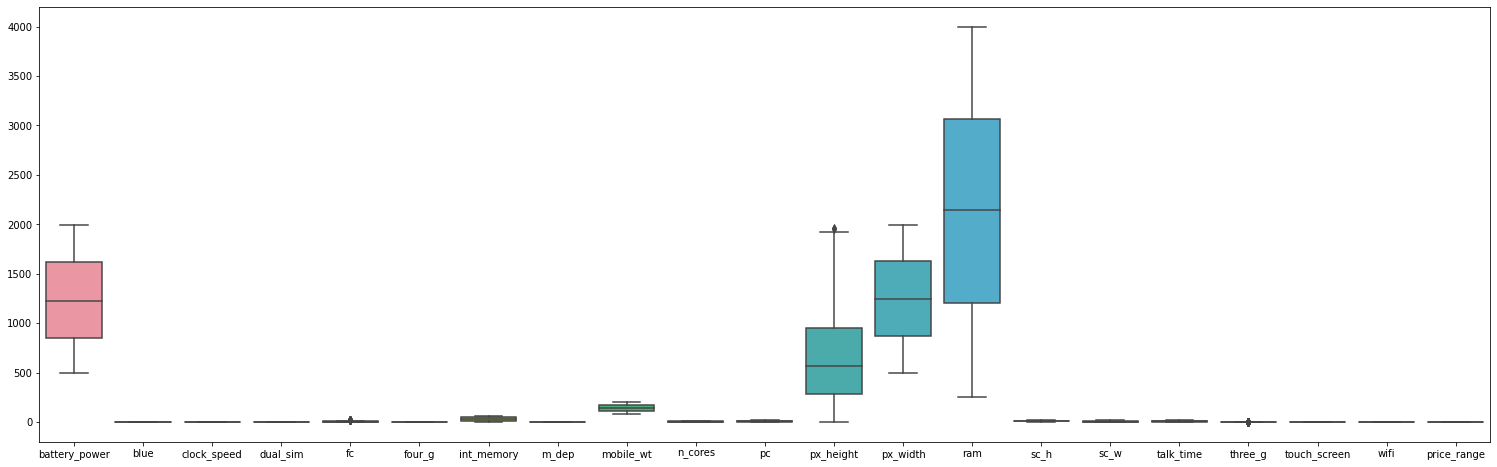

In [0]:
#Finding Outliers 
import seaborn as sns
import matplotlib.pyplot as plt
# Set the figure size
plt.figure(figsize=(26, 8))  # You can adjust the width (12) and height (8) values as needed

# Draw the box plot
sns.boxplot(data=pandas_df)

# Show the plot
plt.show()


In [0]:
df = df.drop("blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi", "int_memory", "m_dep", "n_cores", "sc_h", "sc_w", "talk_time", "three_g", "mobile_wt","clock_speed", "pc", "fc", "blue_vec", "dual_sim_vec", "four_g_vec", "three_g_vec", "wifi_vec", "touch_screen_vec")
df.show()


+-------------+---------+--------+----+-----------+
|battery_power|px_height|px_width| ram|price_range|
+-------------+---------+--------+----+-----------+
|          842|       20|     756|2549|          1|
|         1021|      905|    1988|2631|          2|
|          563|     1263|    1716|2603|          2|
|          615|     1216|    1786|2769|          2|
|         1821|     1208|    1212|1411|          1|
|         1859|     1004|    1654|1067|          1|
|         1821|      381|    1018|3220|          3|
|         1954|      512|    1149| 700|          0|
|         1445|      386|     836|1099|          0|
|          509|     1137|    1224| 513|          0|
|          769|      248|     874|3946|          3|
|         1520|      151|    1005|3826|          3|
|         1815|      607|     748|1482|          1|
|          803|      344|    1440|2680|          2|
|         1866|      356|     563| 373|          0|
|          775|      862|    1864| 568|          0|
|          8

In [0]:
from pyspark import keyword_only  
from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol, Param
from pyspark.sql.functions import udf, min, max
from pyspark.sql.types import ArrayType, StringType


class Scaler(Transformer, HasInputCol, HasOutputCol):

    @keyword_only
    def __init__(self, inputCol=None, outputCol=None):
        super(Scaler, self).__init__()
        self._setDefault(inputCol=None, outputCol=None)
        kwargs = self._input_kwargs
        self.setParams(**kwargs)

    @keyword_only
    def setParams(self, inputCol=None, outputCol=None):
        kwargs = self._input_kwargs
        return self._set(**kwargs)

    def _transform(self, dataset):
        out_col = self.getOutputCol()
        in_col = dataset[self.getInputCol()]
        xmin, xmax = dataset.select(min(in_col), max(in_col)).first()
        return dataset.withColumn(out_col, (in_col - xmin)/(xmax-xmin))


In [0]:
# Assuming num_input is a list of your numeric column names
num_input = ['ram', 'px_width', 'px_height', 'battery_power'] # Replace with your actual numeric column names

scalers = [Scaler(inputCol=column, outputCol=column+"_scaled") for column in num_input]



In [0]:
from pyspark.ml import Pipeline

# Create a pipeline with all the scalers
pipeline = Pipeline(stages=scalers)

# Fit and transform the data using the pipeline
scaled_df = pipeline.fit(df).transform(df)

# Show results
scaled_df.show()


+-------------+---------+--------+----+-----------+--------------------+-------------------+-------------------+--------------------+
|battery_power|px_height|px_width| ram|price_range|          ram_scaled|    px_width_scaled|   px_height_scaled|battery_power_scaled|
+-------------+---------+--------+----+-----------+--------------------+-------------------+-------------------+--------------------+
|          842|       20|     756|2549|          1|  0.6127739176910743|0.17089452603471295|0.01020408163265306| 0.22778891115564462|
|         1021|      905|    1988|2631|          2|  0.6346873329770176| 0.9933244325767691|  0.461734693877551|  0.3473613894455578|
|          563|     1263|    1716|2603|          2|  0.6272047033671834| 0.8117489986648865| 0.6443877551020408|0.041416165664662656|
|          615|     1216|    1786|2769|          2|  0.6715660074826296| 0.8584779706275033| 0.6204081632653061| 0.07615230460921844|
|         1821|     1208|    1212|1411|          1| 0.30865847

In [0]:
train, test = df.randomSplit([0.7, 0.3], seed = 2018) # divides the dataset into training and testing
print("Training Dataset Count: " + str(train.count())) # gives hpow many observations in the training set
print("Test Dataset Count: " + str(test.count())) # gives how many observations in the test set

Training Dataset Count: 1423
Test Dataset Count: 577


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression  # Import LogisticRegression

# List all the feature columns you want to include in the model
# This includes both original and newly created columns (like the *_vec columns from one-hot encoding)
feature_columns = [
    'ram', 'px_width', 'px_height', 'battery_power'
]

assembler = VectorAssembler(inputCols=feature_columns, outputCol="new_features")
train = assembler.transform(train)


lr = LogisticRegression(labelCol="price_range", featuresCol="features", maxIter=10)
logRegModel = lr.fit(train)


In [0]:
# Accessing coefficientMatrix and interceptVector
coefficient_matrix = logRegModel.coefficientMatrix
intercepts = logRegModel.interceptVector

# Get the number of classes and features
num_classes = coefficient_matrix.numRows
num_features = coefficient_matrix.numCols

# Displaying coefficients and intercepts for each class
for i in range(num_classes):
    print(f"Class {i} Coefficients: {coefficient_matrix.toArray()[i]}")
    print(f"Class {i} Intercept: {intercepts[i]}\n")


Class 0 Coefficients: [-0.02164477 -0.00784818 -0.00814137 -0.01307761]
Class 0 Intercept: 69.48994386010399

Class 1 Coefficients: [-0.00570407 -0.00216253 -0.00199512 -0.00361992]
Class 1 Intercept: 27.910703901701556

Class 2 Coefficients: [0.00584851 0.0021056  0.0019829  0.00341084]
Class 2 Intercept: -13.083219611545697

Class 3 Coefficients: [0.02150032 0.0079051  0.00815359 0.01328668]
Class 3 Intercept: -84.31742815025986



In [0]:
logRegModel.transform(train).select('probability', 'prediction').toPandas()

/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field probability. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,probability,prediction
0,"[5.173322119039949e-05, 0.9762020219034976, 0....",1.0
1,"[5.46122413207495e-07, 0.6458207318755969, 0.3...",1.0
2,"[0.01663878745544402, 0.9829910645534679, 0.00...",1.0
3,"[2.5803883711932935e-06, 0.8181289142503133, 0...",1.0
4,"[0.9999999975767511, 2.423248964298514e-09, 2....",0.0
...,...,...
1418,"[1.3116937402640495e-37, 1.1531546079844092e-1...",3.0
1419,"[0.9993523364324615, 0.0006476634976323028, 6....",0.0
1420,"[0.00017676559102984408, 0.9877123458137026, 0...",1.0
1421,"[4.441331586581598e-10, 0.06989026861828217, 0...",2.0


In [0]:
summary = logRegModel.summary # gets the modelo summary and saves it as summary
accuracy = summary.accuracy # access the accuracy within model summary
falsePositiveRate = summary.weightedFalsePositiveRate # access the FPR within model summary
truePositiveRate = summary.weightedTruePositiveRate # access the TPR within model summary
fMeasure = summary.weightedFMeasure() # access the FM within model summary
precision = summary.weightedPrecision # access the precision within model summary
recall = summary.weightedRecall # access the recall within model summary
print("Accuracy: %s\nFPR: %s\nTPR: %s\nF-measure: %s\nPrecision: %s\nRecall: %s"
      % (accuracy, falsePositiveRate, truePositiveRate, fMeasure, precision, recall))

Accuracy: 0.9592410400562192
FPR: 0.013732275831137819
TPR: 0.9592410400562192
F-measure: 0.9593446097239869
Precision: 0.9596787320791277
Recall: 0.9592410400562192


In [0]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Create a Spark session
spark = SparkSession.builder.appName("TreeMethods").getOrCreate()

# Assuming you have a CSV dataset
df = spark.read.csv('dbfs:/FileStore/tables/train.csv', header=True, inferSchema=True)


In [0]:
# Convert the target variable into numerical form (if it's categorical)
label_indexer = StringIndexer(inputCol='price_range', outputCol='label')

# Assemble features into a single vector column
assembler = VectorAssembler(inputCols=["battery_power", "px_height", "px_width", "ram"], outputCol="features")


In [0]:
# Create and train the Decision Tree model
dtc = DecisionTreeClassifier(labelCol='label', featuresCol='features')
pipeline = Pipeline(stages=[label_indexer, assembler, dtc])
model = pipeline.fit(df)
dtc_predictions = model.transform(df)


In [0]:
# Create and train the Random Forest model
rfc = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100
                             )
pipeline = Pipeline(stages=[label_indexer, assembler, rfc])
model = pipeline.fit(df)
rfc_predictions = model.transform(df)


In [0]:
# Evaluate the models
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

dtc_accuracy = evaluator.evaluate(dtc_predictions)
rfc_accuracy = evaluator.evaluate(rfc_predictions)

print(f"Decision Tree Accuracy: {dtc_accuracy}")
print(f"Random Forest Accuracy: {rfc_accuracy}")


Decision Tree Accuracy: 0.8705
Random Forest Accuracy: 0.907


In [0]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Convert the target variable into numerical form (if it's categorical)
label_indexer = StringIndexer(inputCol='price_range', outputCol='label')
assembler = VectorAssembler(inputCols=["battery_power", "px_height", "px_width", "ram"], outputCol="features")

rfc = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=100)
pipeline = Pipeline(stages=[label_indexer, assembler, rfc])
model = pipeline.fit(df)


In [0]:
# Get feature importances from the Random Forest model
rf_model = model.stages[-1]  # Assuming RandomForest is the last stage in the pipeline
importances = rf_model.featureImportances

# Map feature importances to the respective feature names
feature_list = ["battery_power", "px_height", "px_width", "ram"]
importance_list = [importances[i] for i in range(len(feature_list))]
sorted_features = sorted(zip(feature_list, importance_list), key=lambda x: x[1], reverse=True)

for feature, importance in sorted_features:
    print(f"{feature}: {importance}")


ram: 0.8224490116027691
battery_power: 0.08422536159629206
px_width: 0.04837026906366521
px_height: 0.044955357737273625


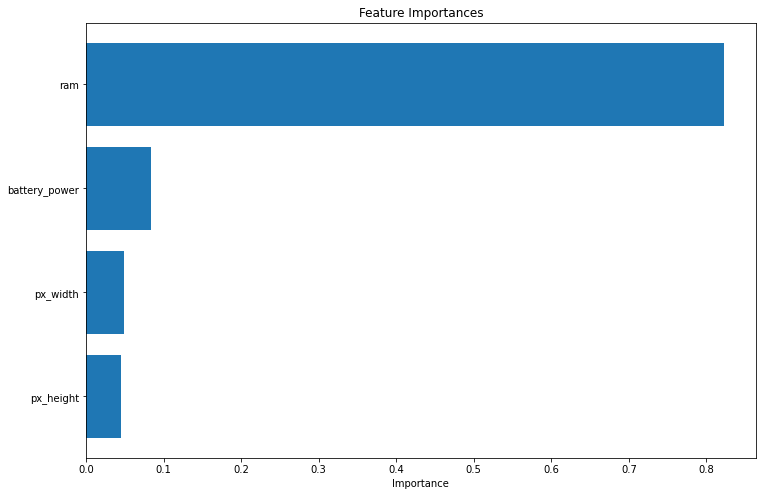

In [0]:
import matplotlib.pyplot as plt

# Extract features and their importances into separate lists
features, importances = zip(*sorted_features)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(features, importances, align='center')
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # To display the feature with the highest importance at the top
plt.show()


RandomForestClassificationModel: uid=RandomForestClassifier_dc15c21e0219, numTrees=100, numClasses=4, numFeatures=4
  Tree 0 (weight 1.0):
    If (feature 3 <= 2263.5)
     If (feature 0 <= 1483.5)
      If (feature 1 <= 887.5)
       If (feature 3 <= 1515.5)
        Predict: 0.0
       Else (feature 3 > 1515.5)
        Predict: 1.0
      Else (feature 1 > 887.5)
       Predict: 1.0
     Else (feature 0 > 1483.5)
      If (feature 3 <= 952.5)
       If (feature 2 <= 1723.5)
        Predict: 0.0
       Else (feature 2 > 1723.5)
        If (feature 0 <= 1526.5)
         Predict: 0.0
        Else (feature 0 > 1526.5)
         Predict: 1.0
      Else (feature 3 > 952.5)
       If (feature 3 <= 1654.0)
        Predict: 1.0
       Else (feature 3 > 1654.0)
        If (feature 1 <= 565.5)
         Predict: 1.0
        Else (feature 1 > 565.5)
         Predict: 2.0
    Else (feature 3 > 2263.5)
     If (feature 2 <= 1058.5)
      If (feature 3 <= 3301.0)
       If (feature 3 <= 2675.5)
       

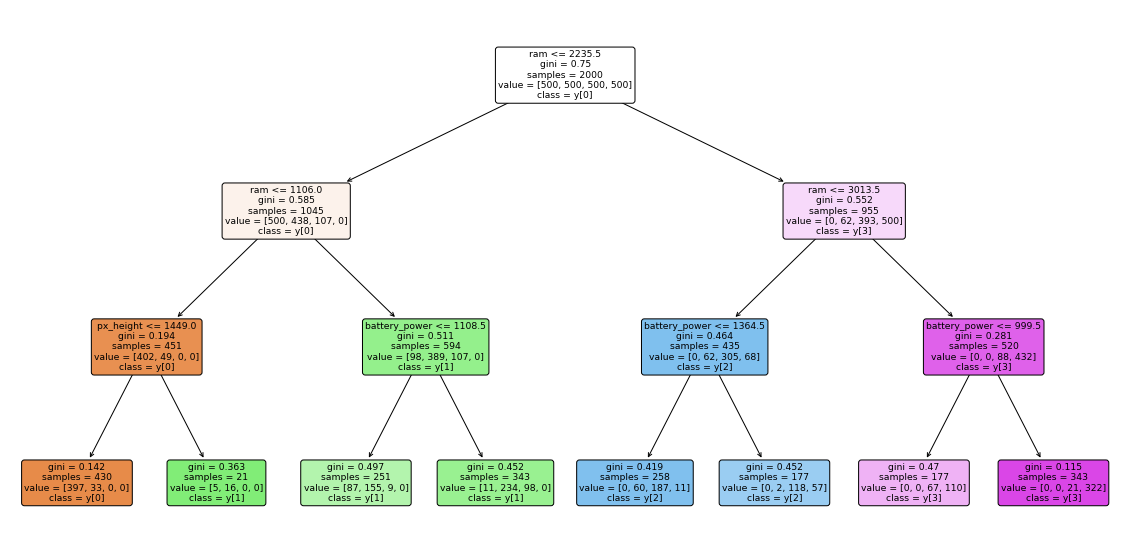

In [0]:
tree_model = model.stages[-1]
print(tree_model.toDebugString)
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas DataFrame for scikit-learn
pdf = df.toPandas()

X = pdf[feature_list]
y = pdf['price_range']

clf = DecisionTreeClassifier(max_depth=3)  # Adjust max_depth as needed
clf.fit(X, y)

plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=feature_list, class_names=True, rounded=True)
plt.show()